In [1]:
import MotifCompendium
mc = MotifCompendium.load("tutorials/chrombpnet_outputs/motif_compendium_annotated.mc", safe=True)


In [2]:
annotation_col="chiptf"
print(f"Number of composite motifs: {(mc[f'{annotation_col}_score1'] > 0).sum()}")


Number of composite motifs: 154


In [7]:
#mc.metadata

In [136]:
#mc[mc[f'{annotation_col}_score1'] > 0]

In [137]:
import MotifCompendium.utils.motif as utils_motif

if "logo (fwd)" not in mc.images():
    mc.add_logos(mc.get_standard_motif_stack(), "logo (fwd)", trim=0)
if "logo (rev)" not in mc.images():
    mc.add_logos(utils_motif.reverse_complement(mc.get_standard_motif_stack()), "logo (rev)", trim=0)

In [138]:
# mc

In [139]:
# import numpy as np
# import pandas as pd
# from IPython.display import Image, display
# import base64
# import gdown

# # View example of a matched motif
# mc.sort(by=f"{annotation_col}_score1", ascending=False, inplace=True)

# logo = mc.get_images('logo (fwd)')
# image_bytes = base64.b64decode(logo[0])
# print(f"Target MC motif: {mc.metadata['name'][0]}")
# display(Image(data=image_bytes, format='png'))

# match_fwd = mc.get_images(f"{annotation_col}_logo0")
# image_bytes = base64.b64decode(match_fwd[0])
# print(f"Matched database motif (first): {mc.metadata[f'{annotation_col}_name0'][0]}")
# display(Image(data=image_bytes, format='png'))

# match_fwd = mc.get_images(f"{annotation_col}_logo1")
# image_bytes = base64.b64decode(match_fwd[0])
# print(f"Matched database motif (second): {mc.metadata[f'{annotation_col}_name1'][0]}")
# display(Image(data=image_bytes, format='png'))

In [140]:
#len(match_fwd)

In [141]:
mc_sub = mc[mc[f'{annotation_col}_score1'] > 0]

In [142]:
#mc_sub

In [143]:
import numpy as np

reference_meme = '/mnt/lab_data2/anusri/MotifCompendium/tutorials/chrombpnet_outputs/meme_invitro_avg.meme.txt'
mcref = MotifCompendium.build_from_pfm({"": reference_meme})

mcref.motifs.shape

(1094, 50, 8)

In [144]:
mcref.metadata.head(2)

,name,posneg,source
0,-ARNT2_0,pos,
1,-ARNTL_0,pos,


In [145]:
mc_sub.metadata.head(1)

,name,num_seqlets,model,posneg,avg_contrib,avg_dist_from_summit,cluster,refdb_score0,refdb_name0,refdb_score1,refdb_name1,chiptf_score0,chiptf_name0,chiptf_score1,chiptf_name1
0,GM12878_counts-pos.pattern_53,29,GM12878_counts,pos,0.665362,71.931034,400,0.659516,DMTF1,0.534466,BATF,0.703261,RELB_0,0.82828,BATF_0


In [146]:
nnames = "-"+mc_sub.metadata["chiptf_name0"]
mcref.motifs[mcref.metadata["name"]==nnames[0]].shape

(1, 50, 8)

In [147]:
# import MotifCompendium.utils.config as utils_config
import MotifCompendium.utils.config as utils_config

####################
# GLOBAL VARIABLES #
####################
_CUPY_IMPORT = None
_RIGHT_TENSOR = None
_LEFT_TENSOR = None

####################
# PUBLIC FUNCTIONS #
####################
from MotifCompendium.utils.similarity_core import *

def _get_array_module():
    if utils_config.get_use_gpu():
        global _CUPY_IMPORT
        if _CUPY_IMPORT is None:
            import cupy as cp

            _CUPY_IMPORT = cp
        return _CUPY_IMPORT
    return np
    
def compute_similarity_and_align_mine(
    motifsA: np.ndarray, motifsB: np.ndarray
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Computes similarity and alignment taking into account reverse complements."""
    # Get array module + prepare motifs
    xp = _get_array_module()
    motifsA_xp = xp.asarray(motifsA, dtype=xp.float64)
    motifsB_xp = xp.asarray(motifsB, dtype=xp.float64)
    # Normalize motifs
    motifsA_normalized = motifsA_xp / xp.linalg.norm(
        motifsA_xp, axis=(1, 2), keepdims=True
    )
    motifsB_normalized = motifsB_xp / xp.linalg.norm(
        motifsB_xp, axis=(1, 2), keepdims=True
    )
    del motifsA_xp, motifsB_xp  # Free up memory
    # Forward similarity
    sim_1, sim_1_alignment = MotifCompendium.utils.similarity_core._compute_similarity(
        motifsA_normalized, motifsB_normalized, xp
    )  # skew-symmetric alignment
    print(sim_1, sim_1_alignment, xp)
    # Reverse complement
    motifsB_normalized_revcomp = MotifCompendium.utils.similarity_core._reverse_complement(motifsB_normalized)
    del motifsB_normalized  # Free up memory
    # Backward similarity
    sim_2, sim_2_alignment = MotifCompendium.utils.similarity_core._compute_similarity(
        motifsA_normalized, motifsB_normalized_revcomp, xp
    )  # symmetric alignment
    # Pick best similarity
    print(sim_2, sim_2_alignment, xp)
    
    sim_12 = xp.stack([sim_1, sim_2])
    sim = xp.max(sim_12, axis=0)
    alignment_rc = xp.argmax(sim_12, axis=0)
    alignment_h = xp.where(alignment_rc == 0, sim_1_alignment, sim_2_alignment)
    # Guarantee similarity properties
    alignment_h[sim == 0] = (
        0  # When 0 similarity, set alignment to 0 for alignment symmetry properties
    )
    # Return
    if utils_config.get_use_gpu():
        sim = sim.get()
        alignment_rc = alignment_rc.get()
        alignment_h = alignment_h.get()
    return (
        sim.astype(np.single),
        alignment_rc.astype(np.bool_),
        alignment_h.astype(np.short),
    )


In [148]:
nnames = "-"+mc_sub.metadata["chiptf_name0"]
print(nnames[0])
my_motifs=mc_sub.motifs[0][None,:,:]
reference_motifs=mcref.motifs[mcref.metadata["name"]==nnames[0]]
if my_motifs.shape[1] > reference_motifs.shape[1]:
    other_pad = self.motifs.shape[1] - reference_motifs.shape[1]
    reference_motifs = np.pad(
        reference_motifs, ((0, 0), (0, other_pad), (0, 0))
    )
elif my_motifs.shape[1] < reference_motifs.shape[1]:
    my_pad = reference_motifs.shape[1] - my_motifs.shape[1]
    my_motifs = np.pad(my_motifs, ((0, 0), (0, my_pad), (0, 0)))
    
compute_similarity_and_align_mine(reference_motifs, my_motifs)

-RELB_0
[[0.69874488]] [[11]] <module 'numpy' from '/users/anusri/anaconda3/envs/motifcompendium/lib/python3.10/site-packages/numpy/__init__.py'>
[[0.45211843]] [[-11]] <module 'numpy' from '/users/anusri/anaconda3/envs/motifcompendium/lib/python3.10/site-packages/numpy/__init__.py'>


(array([[0.6987449]], dtype=float32),
 array([[False]]),
 array([[11]], dtype=int16))

In [149]:
 mc_sub.motifs[0][None,:,:].shape

(1, 30, 8)

In [150]:
nnames[0]

'-RELB_0'

Target MC motif: GM12878_counts-pos.pattern_53


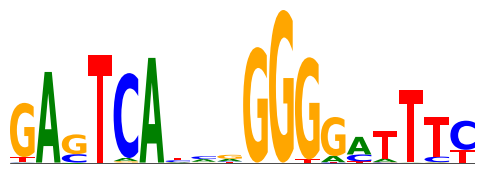

Matched database motif (first): RELB_0


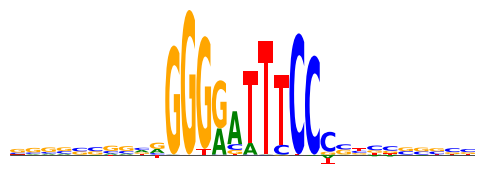

Matched database motif (second): BATF_0


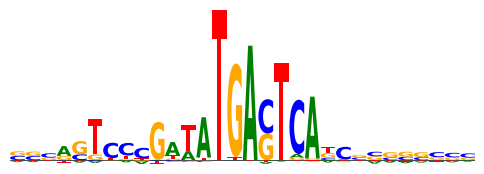

In [151]:
import numpy as np
import pandas as pd
from IPython.display import Image, display
import base64
import gdown

# View example of a matched motif

logo = mc_sub.get_images('logo (fwd)')
image_bytes = base64.b64decode(logo[0])
print(f"Target MC motif: {mc_sub.metadata['name'][0]}")
display(Image(data=image_bytes, format='png'))

match_fwd = mc_sub.get_images(f"{annotation_col}_logo0")
image_bytes = base64.b64decode(match_fwd[0])
print(f"Matched database motif (first): {mc_sub.metadata[f'{annotation_col}_name0'][0]}")
display(Image(data=image_bytes, format='png'))

match_fwd = mc_sub.get_images(f"{annotation_col}_logo1")
image_bytes = base64.b64decode(match_fwd[0])
print(f"Matched database motif (second): {mc_sub.metadata[f'{annotation_col}_name1'][0]}")
display(Image(data=image_bytes, format='png'))

In [152]:
mc_sub.motifs[0][11:][0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.08257816, 0.        , 0.00255861])

In [157]:
from MotifCompendium.utils.motif import motif_8_to_4_signed
motif_8_to_4_signed(mc_sub.motifs[0])

array([[-1.88321283e-04,  2.29790727e-04,  4.38175408e-02,
         4.24902868e-03],
       [ 7.33054952e-02,  0.00000000e+00,  0.00000000e+00,
        -6.85019203e-04],
       [-8.79387986e-04,  6.79508931e-03,  1.60140198e-02,
        -2.74174838e-04],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         8.70800499e-02],
       [ 2.47504842e-03,  6.86848489e-02,  1.21547016e-03,
         0.00000000e+00],
       [ 8.46802107e-02,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [-5.41497313e-04,  1.62762544e-03,  2.81966139e-04,
         2.06941683e-03],
       [ 2.14079628e-03,  2.33530337e-03,  1.51357062e-04,
         4.92899640e-04],
       [ 2.03506937e-03,  5.27508772e-04,  3.26860747e-03,
         4.66290189e-04],
       [ 0.00000000e+00,  0.00000000e+00,  9.33747307e-02,
        -7.09342137e-04],
       [ 0.00000000e+00,  0.00000000e+00,  1.23416737e-01,
         0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  8.25781621e-02,
      

In [159]:
my_motifs=mc_sub.motifs[0][None,:,:]
reference_motifs=mcref.motifs[mcref.metadata["name"]==nnames[0]]
motif1 = motif_8_to_4_signed(my_motifs)
motifs2 = motif_8_to_4_signed(reference_motifs)

In [181]:
from MotifCompendium.utils.motif import trim_motif

trim_motif(motif1[0]).shape



(18, 4)

In [205]:
trim_motif(motifs2[0]).shape

(10, 4)

In [192]:
motifs2[0].min()

np.float64(-0.0014047769936524957)

In [174]:
motif1[0].shape

(30, 4)

In [162]:
motifs2.shape

(1, 50, 4)

In [166]:
 motif1.shape

(1, 30, 4)

In [169]:
trim_motif(motifs2).shape

(1, 50, 4)